In [3]:
using Piccolo
using CairoMakie
using Random;
Random.seed!(42);
using SparseArrays


In [ ]:
# 1. Define the quantum system: H(u) = H_drift + u₁ H_x + u₂ H_y
sys = QuantumSystem(PAULIS[:Z], [PAULIS[:X], PAULIS[:Y]], [1.0, 1.0])

# 2. Initial control pulse
pulse = ZeroOrderPulse(0.1 * randn(2, 100), range(0, 10.0, length=100))

# 3. Trajectory = system + pulse + goal
qtraj = UnitaryTrajectory(sys, pulse, GATES[:X])

# 4. Assemble the NLP
qcp = SmoothPulseProblem(qtraj, 100; Q=100.0, R=1e-2)

# 5. Solve (Ipopt interior-point method)
solve!(qcp; max_iter=100)

# 6. Extract results
fidelity(qcp)
optimized_pulse = get_pulse(qcp.qtraj)

# 7. Save for later (warm-starting, analysis, hardware deployment)
save("x_gate.jld2", optimized_pulse)

In [4]:
# The drift Hamiltonian: ω/2 σ_z (qubit frequency)
# We set ω = 1.0 for simplicity
H_drift = 0.5 * PAULIS[:Z]

# The drive Hamiltonians: σ_x and σ_y controls
H_drives = [PAULIS[:X], PAULIS[:Y]]

# Maximum amplitude for each drive (in same units as H_drift)
drive_bounds = [1.0, 1.0]

# Create the system
sys = QuantumSystem(H_drift, H_drives, drive_bounds)


QuantumSystem: levels = 2, n_drives = 2

In [5]:
# The drift Hamiltonian: ω/2 σ_z (qubit frequency)
# We set ω = 1.0 for simplicity
H_drift = 0.5 * PAULIS[:Z]

# The drive Hamiltonians: σ_x and σ_y controls
H_drives = [PAULIS[:X], PAULIS[:Y]]

# Maximum amplitude for each drive (in same units as H_drift)
drive_bounds = [1.0, 1.0]

# Create the system
sys = QuantumSystem(H_drift, H_drives, drive_bounds)



QuantumSystem: levels = 2, n_drives = 2

In [6]:
# Gate duration and discretization
T = 10.0   # Total time (in units where ω = 1)
N = 100    # Number of timesteps

# Time vector
times = collect(range(0, T, length = N))

# Random initial controls (small amplitude)
# Shape: (n_drives, N) = (2, 100)
initial_controls = 0.1 * randn(2, N)

# Create the pulse
pulse = ZeroOrderPulse(initial_controls, times)


ZeroOrderPulse
  drives: 2
  duration: 10.0

In [ ]:
pulse(1.0)

In [ ]:
# Our target: the X gate
U_goal = GATES[:X]

U_goal

# Create the trajectory
qtraj = UnitaryTrajectory(sys, pulse, U_goal)


In [ ]:
qcp = SmoothPulseProblem(
    qtraj,
    N;
    Q = 100.0,       # Fidelity weight (higher = prioritize fidelity)
    R = 1e-2,        # Regularization weight (higher = smoother controls)
    ddu_bound = 1.0,  # Limit on control acceleration
    piccolo_options = PiccoloOptions(timesteps_all_equal = true),
)


In [ ]:
solve!(qcp; max_iter = 20, verbose = false, print_level = 1)

In [ ]:
fidelity(qcp)

In [ ]:
traj = get_trajectory(qcp)

# Check the final unitary
U_final = iso_vec_to_operator(traj[:Ũ⃗][:, end])
round.(U_final, digits = 3)


In [ ]:
plot_pulse(qcp; bounds = true, labels = ["u_x", "u_y"], title = "Optimized Controls")

In [ ]:
optimized_pulse = get_pulse(qcp.qtraj)
save("x_gate_pulse.jld2", optimized_pulse)


In [ ]:
#=
optimized_pulse = get_pulse(qcp.qtraj)
save("x_gate_pulse.jld2", optimized_pulse)
=#



# MultiLevel Transmon

In [7]:
# define the time parameters

T₀ = 10     # total time in ns
N = 50      # number of time steps
Δt = T₀ / N # time step
times = collect(range(0, T₀, length = N))

# define the system parameters
levels = 5
δ = 0.2

# add a bound to the controls
u_bound = [0.2, 0.2]
ddu_bound = 1.0

# create the system
sys = TransmonSystem(drive_bounds = u_bound, levels = levels, δ = δ)

# let's look at the drives of the system
get_drives(sys)[1] |> sparse


5×5 SparseMatrixCSC{ComplexF64, Int64} with 8 stored entries:
         ⋅      6.28319+0.0im          ⋅              ⋅              ⋅    
 6.28319+0.0im          ⋅      8.88577+0.0im          ⋅              ⋅    
         ⋅      8.88577+0.0im          ⋅      10.8828+0.0im          ⋅    
         ⋅              ⋅      10.8828+0.0im          ⋅      12.5664+0.0im
         ⋅              ⋅              ⋅      12.5664+0.0im          ⋅    

In [8]:
# define the target operator
op = EmbeddedOperator(:X, sys)

# show the full operator
op.operator |> sparse


5×5 SparseMatrixCSC{ComplexF64, Int64} with 2 stored entries:
     ⋅      1.0+0.0im      ⋅          ⋅          ⋅    
 1.0+0.0im      ⋅          ⋅          ⋅          ⋅    
     ⋅          ⋅          ⋅          ⋅          ⋅    
     ⋅          ⋅          ⋅          ⋅          ⋅    
     ⋅          ⋅          ⋅          ⋅          ⋅    

In [9]:
# create a random initial pulse
initial_controls = 0.1 * randn(2, N)
pulse = ZeroOrderPulse(initial_controls, times)

# create a unitary trajectory with the embedded operator as goal
qtraj = UnitaryTrajectory(sys, pulse, op)

# create the optimization problem
qcp_t = SmoothPulseProblem(qtraj, N; ddu_bound = ddu_bound, Q = 100.0, R = 1e-2)


constructing SmoothPulseProblem [UnitaryTrajectory]


┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /Users/jettajb1/.julia/packages/DirectTrajOpt/VOKy2/src/problems.jl:66


QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=5   drives=2
│  
├─ Trajectory
│    N=50   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (50)  ±[1.0, 1.0, 1.0, … (50 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [5], subspace dim 2
│  
├─ Objective   total = 73.17  @ current x
│    KnotPointObjective           w=1             72.4
│    QuadraticRegularizer(:u)     w=1             1.957e-04
│    QuadraticRegularizer(:du)    w=1             0.0106
│    QuadraticRegularizer(:ddu)   w=1             0.7642
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│    

QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=5   drives=2
│  
├─ Trajectory
│    N=50   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (50)  ±[1.0, 1.0, 1.0, … (50 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [5], subspace dim 2
│  
├─ Objective   total = 73.17  @ current x
│    KnotPointObjective           w=1             72.4
│    QuadraticRegularizer(:u)     w=1             1.957e-04
│    QuadraticRegularizer(:du)    w=1             0.0106
│    QuadraticRegularizer(:ddu)   w=1             0.7642
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│    

In [10]:
solve!(qcp_t; max_iter= 50)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:   304112
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   245385

Total number of variables............................:     2845
                     variables with only lower bounds:       50
                variables with lower and upper bounds:     2646
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2695
Total number of inequality c

In [11]:
fid = fidelity(qcp_t)
println("Fidelity: ", fid)

Fidelity: 0.9998779619811069


In [12]:
# create a leakage suppression problem
qcp_leakage = SmoothPulseProblem(
    qtraj,
    N;
    ddu_bound = ddu_bound,
    Q = 100.0,
    R = 1e-2,
    piccolo_options = PiccoloOptions(
        leakage_constraint = true,
        leakage_constraint_value = 1e-2,
        leakage_cost = 1e-2,
    ),
)

# solve the problem
solve!(qcp_leakage; max_iter = 50)


constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=5   drives=2
│  
├─ Trajectory
│    N=50   T=9.997   Δt∈[0, Inf]
│    Ũ⃗    (50)  ±[1.0, 1.0, 1.0, … (50 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [5], subspace dim 2
│  
├─ Objective   total = 0.04213  @ current x
│    KnotPointObjective           w=1             0.0122
│    QuadraticRegularizer(:u)     w=1             4.750e-05
│    QuadraticRegularizer(:du)    w=1             5.120e-04
│    QuadraticRegularizer(:ddu)   w=1             0.02097
│    NullObjective                w=1  

In [14]:
fid_leakage = fidelity(qcp_leakage)
println("Fidelity with leakage suppression: ", fid_leakage)


Fidelity with leakage suppression: 0.7741671259133067


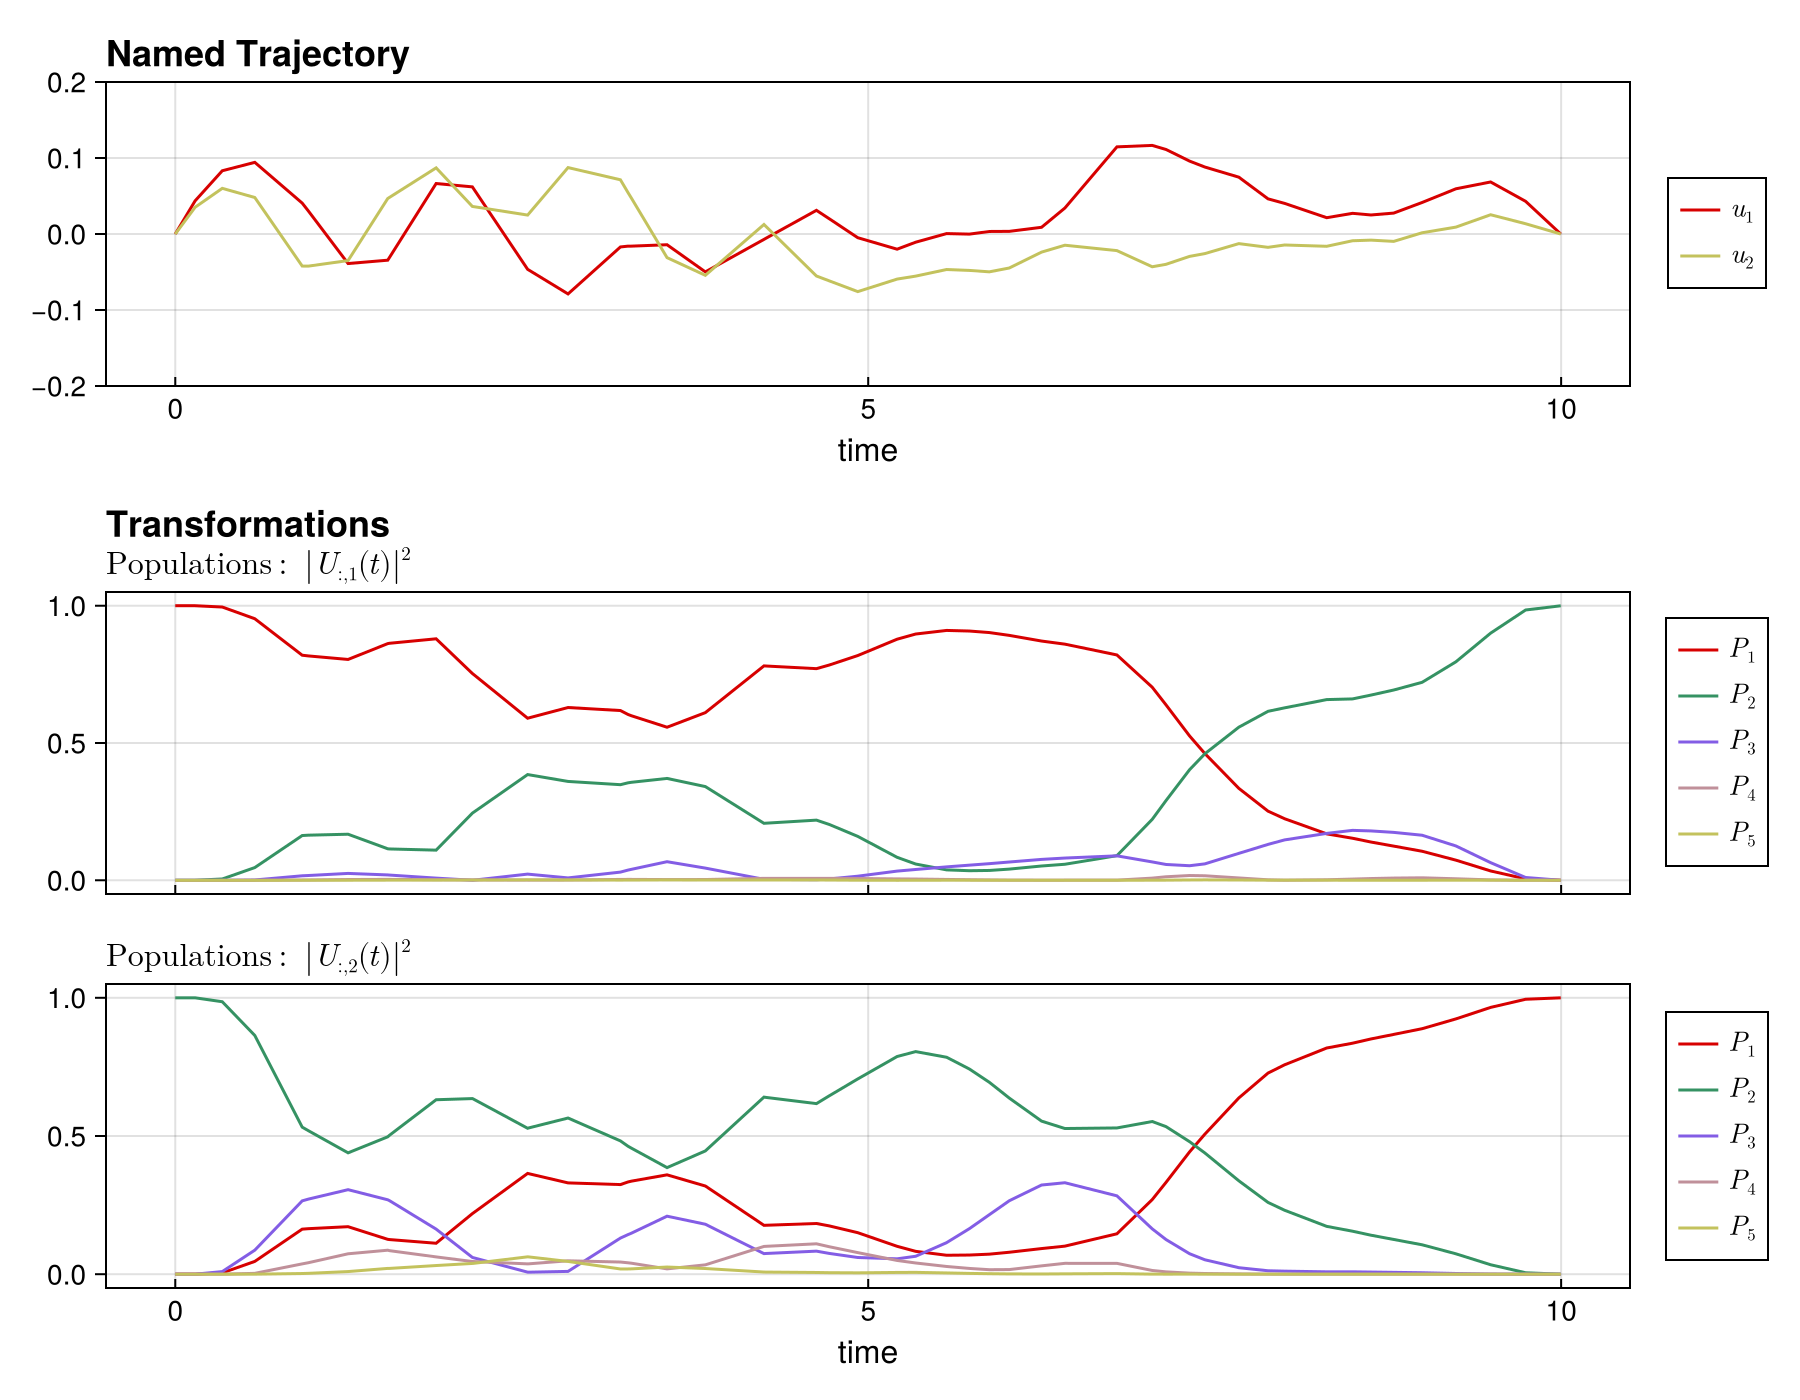

In [16]:
plot_unitary_populations(get_trajectory(qcp_t); fig_size = (900, 700))


# STATE TRANSFER

In [13]:
# Create quantum system
H_drift = 0.5 * PAULIS[:Z]
H_drives = [PAULIS[:X], PAULIS[:Y]]
sys = QuantumSystem(H_drift, H_drives, [1.0, 1.0])

# Time parameters
T, N = 10.0, 100
times = collect(range(0, T, length = N))

# Initial pulse
pulse = ZeroOrderPulse(0.1 * randn(2, N), times)


ZeroOrderPulse
  drives: 2
  duration: 10.0

In [17]:
# Initial state: |0⟩
ψ_init = ComplexF64[1.0, 0.0]

# Target state: |1⟩
ψ_goal = ComplexF64[0.0, 1.0]

# Create KetTrajectory
qtraj = KetTrajectory(sys, pulse, ψ_init, ψ_goal)


KetTrajectory
  system: 2-level QuantumSystem
  drives: ZeroOrderPulse with 2 drives
  duration: 10.0

In [18]:
qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, R = 1e-2)
solve!(qcp; max_iter = 20, verbose = false, print_level = 1)

fidelity(qcp)


constructing SmoothPulseProblem [KetTrajectory]
QuantumControlProblem
├─ KetTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    ψ̃    (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    Δt   (1)  [0.0, Inf]             ✓  timestep
│    t    (1)                         ·  state
│    u    (2)  ±[1.0, 1.0]            ✓  control
│    du   (2)                         ·  control
│    ddu  (2)  ±[1.0, 1.0]            ✓  control
│  
├─ Goal
│    |ψ_init⟩ → |ψ_goal⟩  (dim=2)
│  
├─ Objective   total = 106.1  @ current x
│    KnotPointObjective           w=1             99.67
│    QuadraticRegularizer(:u)     w=1             1.128e-04
│    QuadraticRegularizer(:du)    w=1             0.02192
│    QuadraticRegularizer(:ddu)   w=1             6.455
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│    [dyn]  BilinearIntegrator

0.9993357687021404

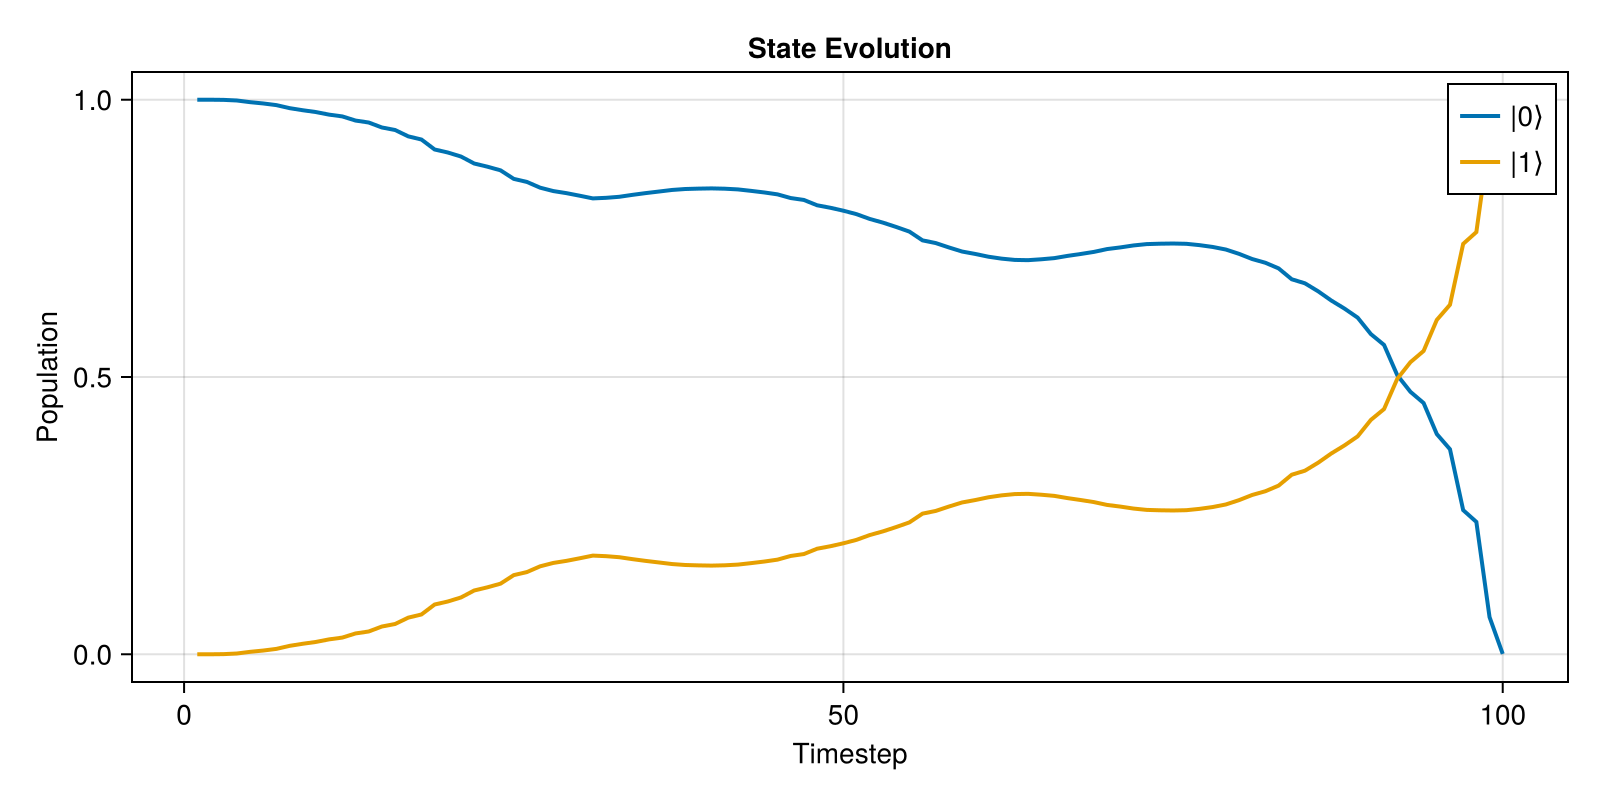

In [19]:
traj = get_trajectory(qcp)

# Convert isomorphic states to physical states
n_steps = size(traj[:ψ̃], 2)
populations = zeros(2, n_steps)

for k = 1:n_steps
    ψ = iso_to_ket(traj[:ψ̃][:, k])
    populations[:, k] = abs2.(ψ)
end

# Plot
fig = Figure(size = (800, 400))

ax1 = Axis(fig[1, 1], xlabel = "Timestep", ylabel = "Population", title = "State Evolution")
lines!(ax1, 1:n_steps, populations[1, :], label = "|0⟩", linewidth = 2)
lines!(ax1, 1:n_steps, populations[2, :], label = "|1⟩", linewidth = 2)
axislegend(ax1, position = :rt)

fig


In [20]:
# Basis states
ψ0 = ComplexF64[1.0, 0.0]  # |0⟩
ψ1 = ComplexF64[0.0, 1.0]  # |1⟩

# Initial states and their targets
initial_states = [ψ0, ψ1]
goal_states = [ψ1, ψ0]  # X gate swaps them

# Create new pulse for this problem
pulse_multi = ZeroOrderPulse(0.1 * randn(2, N), times)

# Create MultiKetTrajectory
qtraj_multi = MultiKetTrajectory(sys, pulse_multi, initial_states, goal_states)


MultiKetTrajectory
  system: 2-level QuantumSystem
  drives: ZeroOrderPulse with 2 drives
  duration: 10.0

In [21]:
qcp_multi = SmoothPulseProblem(qtraj_multi, N; Q = 100.0, R = 1e-2)
solve!(
    qcp_multi;
    max_iter = 20,
    verbose = false,
    print_level = 1,
)

fidelity(qcp_multi)


    constructing SmoothPulseProblem for MultiKetTrajectory (2 states)...
QuantumControlProblem
├─ MultiKetTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    ψ̃1   (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    ψ̃2   (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    Δt   (1)  [0.0, Inf]             ✓  timestep
│    t    (1)                         ·  state
│    u    (2)  ±[1.0, 1.0]            ✓  control
│    du   (2)                         ·  control
│    ddu  (2)  ±[1.0, 1.0]            ✓  control
│  
├─ Goal
│    2 state transfers  (dim=2)
│  
├─ Objective   total = 106.1  @ current x
│    KnotPointObjective           w=1             99.76
│    QuadraticRegularizer(:u)     w=1             1.119e-04
│    QuadraticRegularizer(:du)    w=1             0.02242
│    QuadraticRegularizer(:ddu)   w=1             6.283
│    NullObjective         

0.9948378315452606

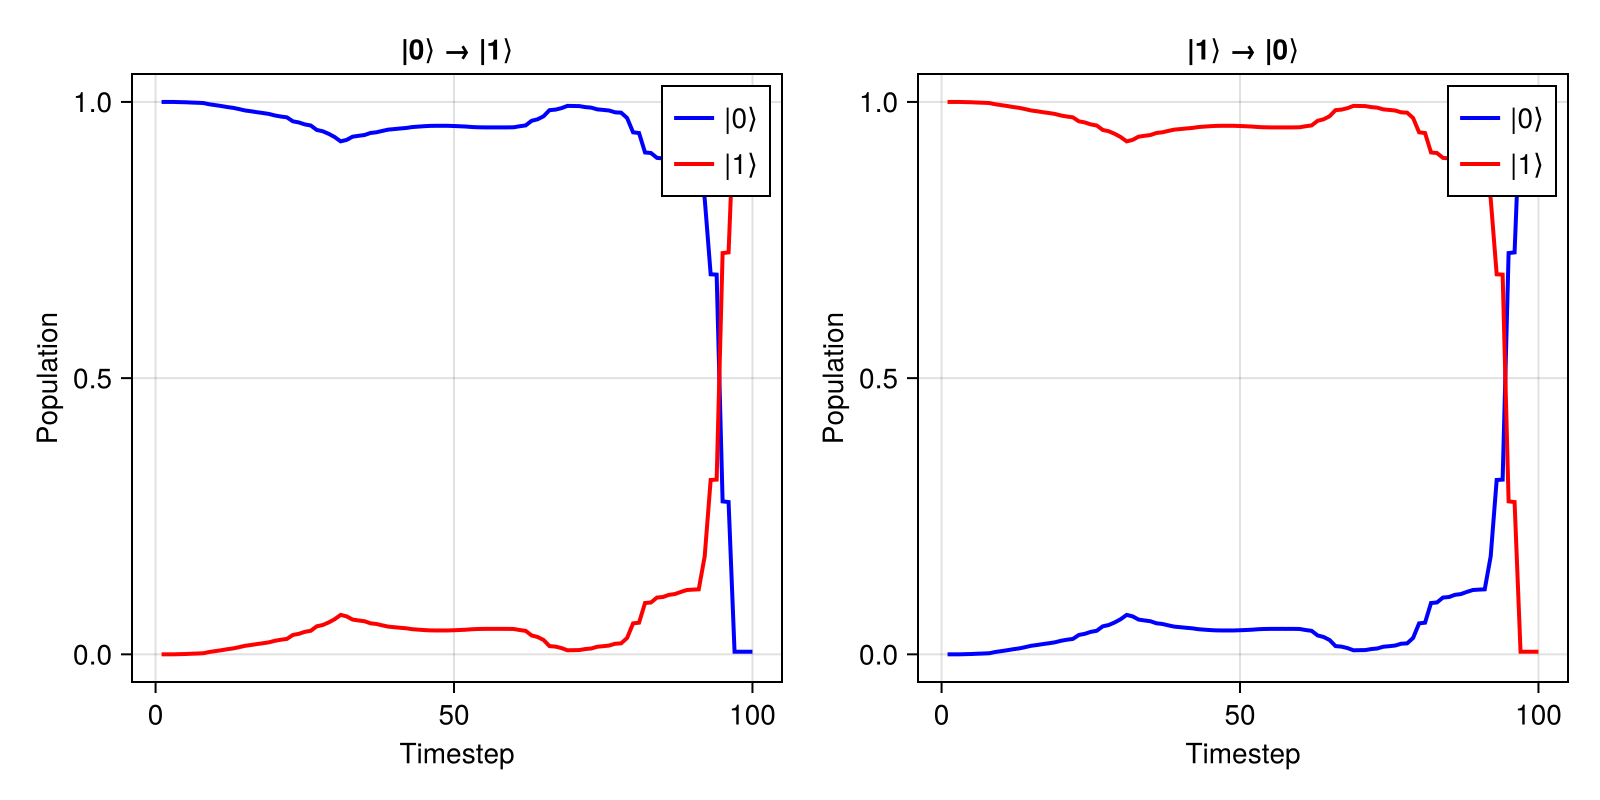

In [22]:
traj_multi = get_trajectory(qcp_multi)

# Extract populations for both initial states
# MultiKetTrajectory stores states as :ψ̃1, :ψ̃2, etc.
n_steps = size(traj_multi[:ψ̃1], 2)

pops1 = zeros(2, n_steps)  # Evolution from |0⟩
pops2 = zeros(2, n_steps)  # Evolution from |1⟩

for k = 1:n_steps
    ψ1_k = iso_to_ket(traj_multi[:ψ̃1][:, k])
    ψ2_k = iso_to_ket(traj_multi[:ψ̃2][:, k])
    pops1[:, k] = abs2.(ψ1_k)
    pops2[:, k] = abs2.(ψ2_k)
end

fig2 = Figure(size = (800, 400))

ax1 = Axis(fig2[1, 1], xlabel = "Timestep", ylabel = "Population", title = "|0⟩ → |1⟩")
lines!(ax1, 1:n_steps, pops1[1, :], label = "|0⟩", linewidth = 2, color = :blue)
lines!(ax1, 1:n_steps, pops1[2, :], label = "|1⟩", linewidth = 2, color = :red)
axislegend(ax1, position = :rt)

ax2 = Axis(fig2[1, 2], xlabel = "Timestep", ylabel = "Population", title = "|1⟩ → |0⟩")
lines!(ax2, 1:n_steps, pops2[1, :], label = "|0⟩", linewidth = 2, color = :blue)
lines!(ax2, 1:n_steps, pops2[2, :], label = "|1⟩", linewidth = 2, color = :red)
axislegend(ax2, position = :rt)

fig2


In [23]:
ψ_plus = ComplexF64[1, 1] / sqrt(2)

pulse_super = ZeroOrderPulse(0.1 * randn(2, N), times)
qtraj_super = KetTrajectory(sys, pulse_super, ψ0, ψ_plus)

qcp_super = SmoothPulseProblem(qtraj_super, N; Q = 100.0, R = 1e-2)
solve!(
    qcp_super;
    max_iter = 20,
    verbose = false,
    print_level = 1,
)

fidelity(qcp_super)


constructing SmoothPulseProblem [KetTrajectory]
QuantumControlProblem
├─ KetTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    ψ̃    (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    Δt   (1)  [0.0, Inf]             ✓  timestep
│    t    (1)                         ·  state
│    u    (2)  ±[1.0, 1.0]            ✓  control
│    du   (2)                         ·  control
│    ddu  (2)  ±[1.0, 1.0]            ✓  control
│  
├─ Goal
│    |ψ_init⟩ → |ψ_goal⟩  (dim=2)
│  
├─ Objective   total = 68.92  @ current x
│    KnotPointObjective           w=1             62.98
│    QuadraticRegularizer(:u)     w=1             9.714e-05
│    QuadraticRegularizer(:du)    w=1             0.02062
│    QuadraticRegularizer(:ddu)   w=1             5.915
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│    [dyn]  BilinearIntegrator

0.9876310585505821

In [24]:
traj_super = get_trajectory(qcp_super)
ψ_final = iso_to_ket(traj_super[:ψ̃][:, end])
round.(ψ_final, digits = 3)


2-element Vector{ComplexF64}:
 0.589 + 0.284im
 0.631 + 0.431im

# ROBUST CONTROL

In [25]:
# Nominal qubit frequency
ω_nominal = 0.5

H_drift = ω_nominal * PAULIS[:Z]
H_drives = [PAULIS[:X], PAULIS[:Y]]
drive_bounds = [1.0, 1.0]

sys_nominal = QuantumSystem(H_drift, H_drives, drive_bounds)

# Time parameters
T, N = 10.0, 100
times = collect(range(0, T, length = N))

# Target gate
U_goal = GATES[:X]


2×2 Matrix{ComplexF64}:
 0.0+0.0im  1.0+0.0im
 1.0+0.0im  0.0+0.0im

In [27]:
# Nominal qubit frequency
ω_nominal = 0.5

H_drift = ω_nominal * PAULIS[:Z]
H_drives = [PAULIS[:X], PAULIS[:Y]]
drive_bounds = [1.0, 1.0]

sys_nominal = QuantumSystem(H_drift, H_drives, drive_bounds)

# Time parameters
T, N = 10.0, 100
times = collect(range(0, T, length = N))

# Target gate
U_goal = GATES[:X]


2×2 Matrix{ComplexF64}:
 0.0+0.0im  1.0+0.0im
 1.0+0.0im  0.0+0.0im

In [29]:
pulse_nom = ZeroOrderPulse(0.1 * randn(2, N), times)
qtraj_nom = UnitaryTrajectory(sys_nominal, pulse_nom, U_goal)

qcp_nom = SmoothPulseProblem(qtraj_nom, N; Q = 100.0, R = 1e-2)
solve!(qcp_nom; max_iter = 20, verbose = false, print_level = 1)

fidelity(qcp_nom)


constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Δt   (1)  [0.0, Inf]                     ✓  timestep
│    t    (1)                                 ·  state
│    u    (2)  ±[1.0, 1.0]                    ✓  control
│    du   (2)                                 ·  control
│    ddu  (2)  ±[1.0, 1.0]                    ✓  control
│  
├─ Goal
│    U_goal  (2×2)
│  
├─ Objective   total = 107.1  @ current x
│    KnotPointObjective           w=1             99.91
│    QuadraticRegularizer(:u)     w=1             1.245e-04
│    QuadraticRegularizer(:du)    w=1             0.02504
│    QuadraticRegularizer(:ddu)   w=1             7.125
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 viol

0.9999894336082589

In [30]:
function evaluate_fidelity(qcp, ω_test)
    # Create test system with different frequency
    H_test = ω_test * PAULIS[:Z]
    sys_test = QuantumSystem(H_test, H_drives, drive_bounds)

    # Get optimized pulse
    pulse_opt = get_pulse(qcp.qtraj)

    # Create trajectory and evaluate
    qtraj_test = UnitaryTrajectory(sys_test, pulse_opt, U_goal)
    return fidelity(qtraj_test)
end

# Test across frequency range
ω_range = range(0.9 * ω_nominal, 1.1 * ω_nominal, length = 21)
fidelities_nom = [evaluate_fidelity(qcp_nom, ω) for ω in ω_range]

extrema(fidelities_nom)


(0.8650204370598726, 0.9999894336082589)

In [31]:
# Create perturbed systems (±5% and ±10%)
ω_samples = [0.9, 0.95, 1.0, 1.05, 1.1] .* ω_nominal
systems = [QuantumSystem(ω * PAULIS[:Z], H_drives, drive_bounds) for ω in ω_samples]

# Optimize for all frequency samples

# Start from the nominal solution
qcp_robust = SamplingProblem(qcp_nom, systems; Q = 100.0)
solve!(
    qcp_robust;
    max_iter = 20,
    verbose = false,
    print_level = 1,
)

fidelity(qcp_robust)


constructing SamplingProblem
    systems: 5
QuantumControlProblem
├─ SamplingTrajectory  ·  BilinearIntegrator, BilinearIntegrator, BilinearIntegrator, BilinearIntegrator, BilinearIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=11.711   Δt∈[0, Inf]
│    Ũ⃗1   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗2   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗3   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗4   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗5   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Δt   (1)  [0.0, Inf]                     ✓  timestep
│    t    (1)                                 ·  state
│    u    (2)  ±[1.0, 1.0]                    ✓  control
│  
├─ Goal
│    sampled ensemble (n=5)
│  
├─ Objective   total = 5.782e-03  @ current x
│    KnotPointObjective         w=1             1.057e-03
│    KnotPointObjective         w=1             1.057e-03
│    KnotPointObjective         w=1             1.057e-03
│    

5-element Vector{Float64}:
 0.9723788826798737
 0.9927781755141153
 0.9994842588742772
 0.9944638236095398
 0.9798319348911134

In [32]:
# Evaluate robust pulse
fidelities_robust = Float64[]
for ω in ω_range
    H_test = ω * PAULIS[:Z]
    sys_test = QuantumSystem(H_test, H_drives, drive_bounds)
    pulse_robust = get_pulse(qcp_robust.qtraj)
    qtraj_test = UnitaryTrajectory(sys_test, pulse_robust, U_goal)
    push!(fidelities_robust, fidelity(qtraj_test))
end

extrema(fidelities_robust)


(0.9723788826798737, 0.9994842588742772)

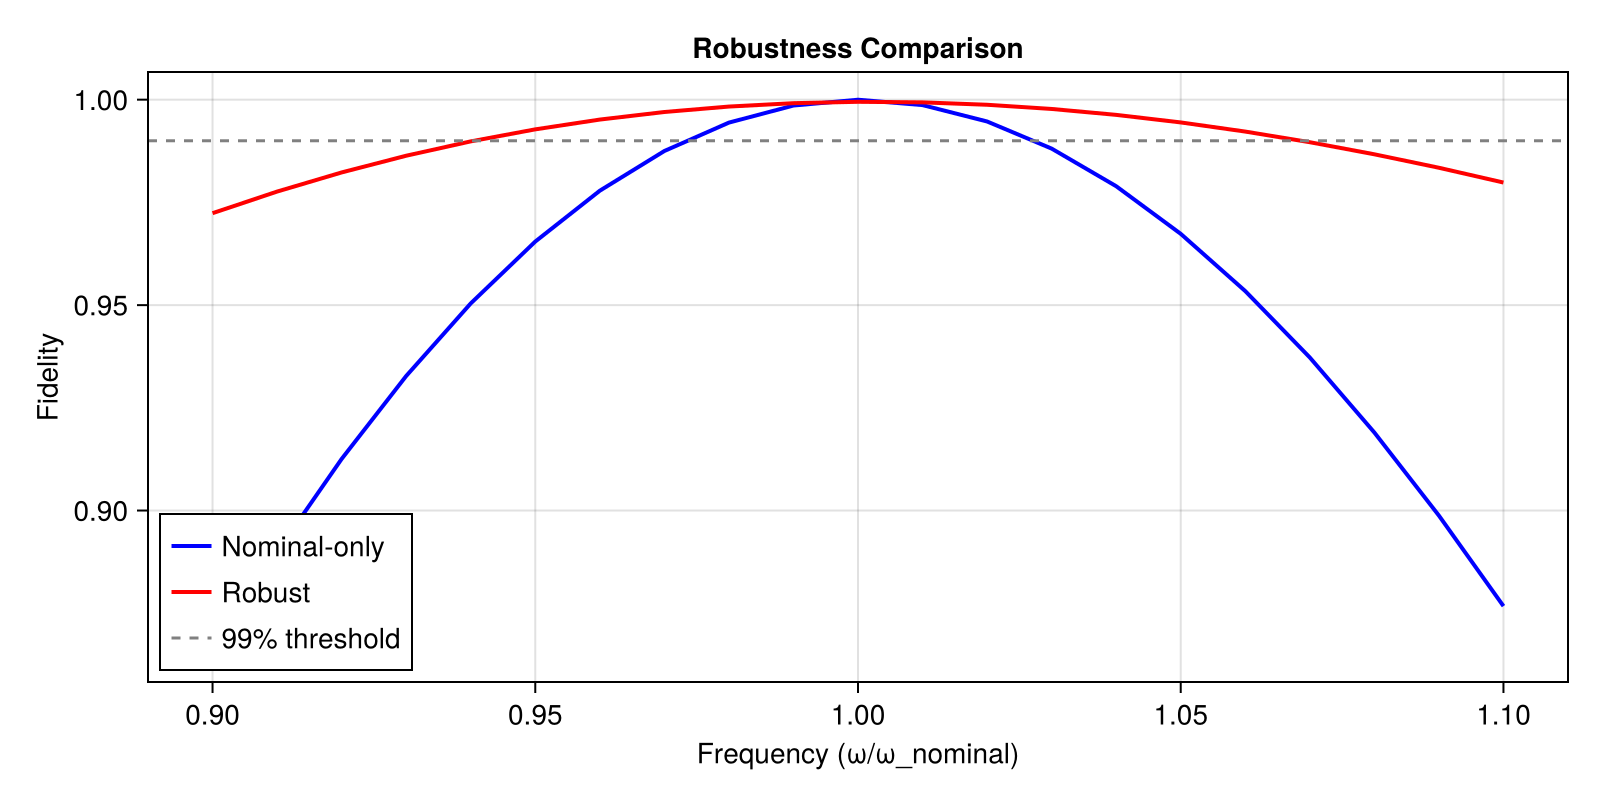

In [33]:
fig = Figure(size = (800, 400))

ax = Axis(
    fig[1, 1],
    xlabel = "Frequency (ω/ω_nominal)",
    ylabel = "Fidelity",
    title = "Robustness Comparison",
)

lines!(
    ax,
    ω_range ./ ω_nominal,
    fidelities_nom,
    label = "Nominal-only",
    linewidth = 2,
    color = :blue,
)
lines!(
    ax,
    ω_range ./ ω_nominal,
    fidelities_robust,
    label = "Robust",
    linewidth = 2,
    color = :red,
)

hlines!(ax, [0.99], linestyle = :dash, color = :gray, label = "99% threshold")

axislegend(ax, position = :lb)

fig


In [34]:
# First, create base problem with free time
pulse_free = ZeroOrderPulse(0.1 * randn(2, N), times)
qtraj_free = UnitaryTrajectory(sys_nominal, pulse_free, U_goal)

qcp_free = SmoothPulseProblem(
    qtraj_free,
    N;
    Q = 100.0,
    R = 1e-2,
    Δt_bounds = (0.05, 0.3),  # Enable variable timesteps
)
solve!(qcp_free; max_iter = 15, verbose = false, print_level = 1)

# Add robustness
qcp_robust_free = SamplingProblem(qcp_free, systems; Q = 100.0)
solve!(
    qcp_robust_free;
    max_iter = 15,
    verbose = false,
    print_level = 1,
)

# Minimize time while maintaining fidelity
qcp_fast_robust = MinimumTimeProblem(qcp_robust_free; final_fidelity = 0.95, D = 100.0)
solve!(
    qcp_fast_robust;
    max_iter = 15,
    verbose = false,
    print_level = 1,
)

# Compare durations
duration_initial = sum(get_timesteps(get_trajectory(qcp_free)))
duration_robust = sum(get_timesteps(get_trajectory(qcp_robust_free)))
duration_fast = sum(get_timesteps(get_trajectory(qcp_fast_robust)))

duration_initial, duration_robust, duration_fast


constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0.05, 0.3]
│    Ũ⃗    (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Δt   (1)  [0.05, 0.3]                    ✓  timestep
│    t    (1)                                 ·  state
│    u    (2)  ±[1.0, 1.0]                    ✓  control
│    du   (2)                                 ·  control
│    ddu  (2)  ±[1.0, 1.0]                    ✓  control
│  
├─ Goal
│    U_goal  (2×2)
│  
├─ Objective   total = 103.5  @ current x
│    KnotPointObjective           w=1             98.72
│    QuadraticRegularizer(:u)     w=1             9.693e-05
│    QuadraticRegularizer(:du)    w=1             0.01741
│    QuadraticRegularizer(:ddu)   w=1             4.728
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 v

(11.75119745197464, 11.434854820520385, 11.12349640978261)

In [35]:
# More weight on nominal, less on extremes
weights = [0.5, 1.0, 2.0, 1.0, 0.5]  # Emphasize nominal

qcp_weighted = SamplingProblem(qcp_nom, systems; weights = weights, Q = 100.0)
solve!(
    qcp_weighted;
    max_iter = 15,
    verbose = false,
    print_level = 1,
)

# Evaluate
fidelities_weighted = Float64[]
for ω in ω_range
    H_test = ω * PAULIS[:Z]
    sys_test = QuantumSystem(H_test, H_drives, drive_bounds)
    pulse_w = get_pulse(qcp_weighted.qtraj)
    qtraj_test = UnitaryTrajectory(sys_test, pulse_w, U_goal)
    push!(fidelities_weighted, fidelity(qtraj_test))
end

extrema(fidelities_weighted)


constructing SamplingProblem
    systems: 5
QuantumControlProblem
├─ SamplingTrajectory  ·  BilinearIntegrator, BilinearIntegrator, BilinearIntegrator, BilinearIntegrator, BilinearIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=11.833   Δt∈[0, Inf]
│    Ũ⃗1   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗2   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗3   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗4   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Ũ⃗5   (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Δt   (1)  [0.0, Inf]                     ✓  timestep
│    t    (1)                                 ·  state
│    u    (2)  ±[1.0, 1.0]                    ✓  control
│  
├─ Goal
│    sampled ensemble (n=5)
│  
├─ Objective   total = 0.259  @ current x
│    KnotPointObjective         w=1             0.02579
│    KnotPointObjective         w=1             0.05157
│    KnotPointObjective         w=1             0.1031
│    KnotPointOb

(0.9993029361296825, 0.9999568564214169)